In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving working_data_IGE.csv to working_data_IGE.csv


In [ ]:
df = pd.read_csv('working_data_IGE.csv')

In [ ]:
df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8047 entries, 0 to 8046
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Pc_name         8047 non-null   object 
 1   no              8047 non-null   object 
 2   type            8015 non-null   object 
 3   state           8047 non-null   object 
 4   candidate_name  8047 non-null   object 
 5   party           8047 non-null   object 
 6   electors        8047 non-null   object 
 7   votes           8047 non-null   object 
 8   Turnout         8033 non-null   object 
 9   margin          8047 non-null   object 
 10  margin%         8032 non-null   object 
 11  year            8046 non-null   float64
dtypes: float64(1), object(11)
memory usage: 754.5+ KB


,year
count,8046.000000
mean,1990.962963
std,16.450377
min,1962.000000
25%,1977.000000
50%,1991.000000
75%,2004.000000
max,2019.000000


In [ ]:
def clean_numeric(col):
    return (
        col.astype(str)
        .str.replace(',', '', regex=False)
        .replace('-', np.nan)
        .pipe(pd.to_numeric, errors='coerce')
    )

df['electors'] = clean_numeric(df['electors'])
df['votes'] = clean_numeric(df['votes'])
df['margin'] = clean_numeric(df['margin'])

df['Turnout'] = (
    df['Turnout']
    .astype(str)
    .str.replace('%', '', regex=False)
)

df['margin%'] = (
    df['margin%']
    .astype(str)
    .str.replace('%', '', regex=False)
)

df['Turnout'] = pd.to_numeric(df['Turnout'], errors='coerce')
df['margin%'] = pd.to_numeric(df['margin%'], errors='coerce')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8047 entries, 0 to 8046
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Pc_name         8047 non-null   object 
 1   no              8047 non-null   object 
 2   type            8015 non-null   object 
 3   state           8047 non-null   object 
 4   candidate_name  8047 non-null   object 
 5   party           8047 non-null   object 
 6   electors        8007 non-null   float64
 7   votes           7993 non-null   float64
 8   Turnout         7993 non-null   float64
 9   margin          7993 non-null   float64
 10  margin%         7993 non-null   float64
 11  year            8046 non-null   float64
dtypes: float64(6), object(6)
memory usage: 754.5+ KB


In [ ]:
df.isnull().sum()

,0
Pc_name,0
no,0
type,32
state,0
candidate_name,0
party,0
electors,40
votes,54
Turnout,54
margin,54


In [ ]:
df = df.dropna()

In [ ]:
df.to_csv('cleaned_election_data.csv', index=False)

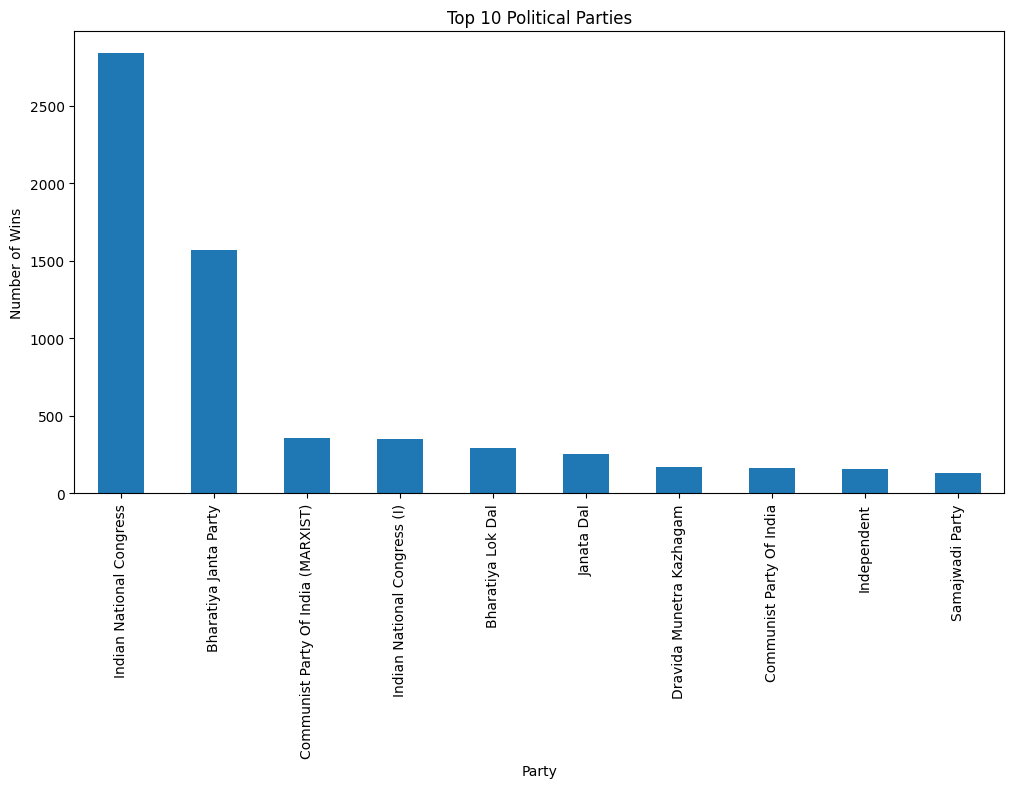

In [ ]:
top_parties = df['party'].value_counts().head(10)

plt.figure(figsize=(12,6))
top_parties.plot(kind='bar')

plt.title('Top 10 Political Parties')
plt.xlabel('Party')
plt.ylabel('Number of Wins')

plt.show()

In [ ]:
df['state'].nunique()

45

In [ ]:
df['party'].nunique()

146

In [ ]:
sorted(df['year'].unique())

[np.float64(1962.0),
 np.float64(1967.0),
 np.float64(1971.0),
 np.float64(1977.0),
 np.float64(1980.0),
 np.float64(1984.0),
 np.float64(1989.0),
 np.float64(1991.0),
 np.float64(1996.0),
 np.float64(1998.0),
 np.float64(1999.0),
 np.float64(2004.0),
 np.float64(2009.0),
 np.float64(2014.0),
 np.float64(2019.0)]

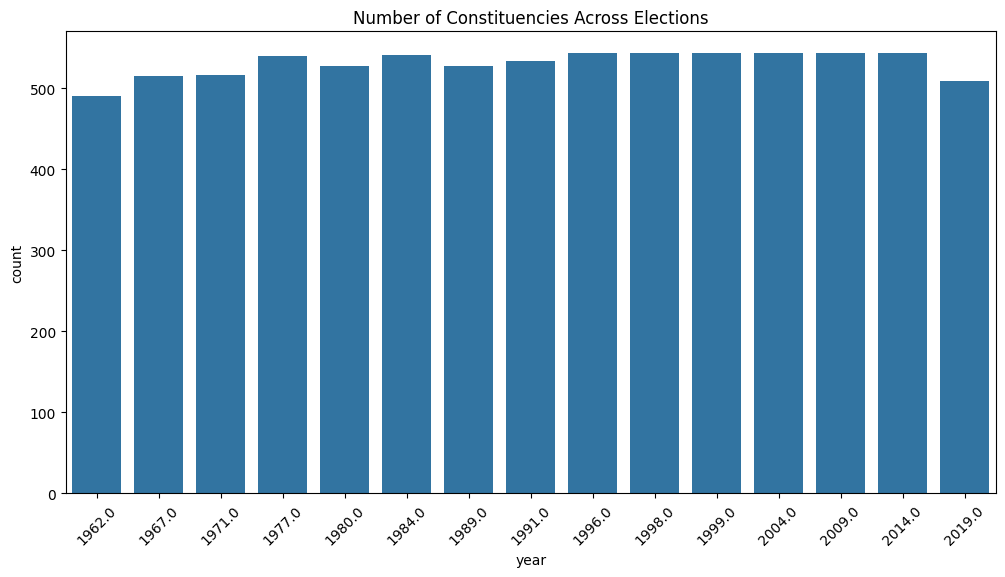

In [ ]:
plt.figure(figsize=(12,6))

sns.countplot(x='year', data=df)

plt.title('Number of Constituencies Across Elections')
plt.xticks(rotation=45)

plt.show()

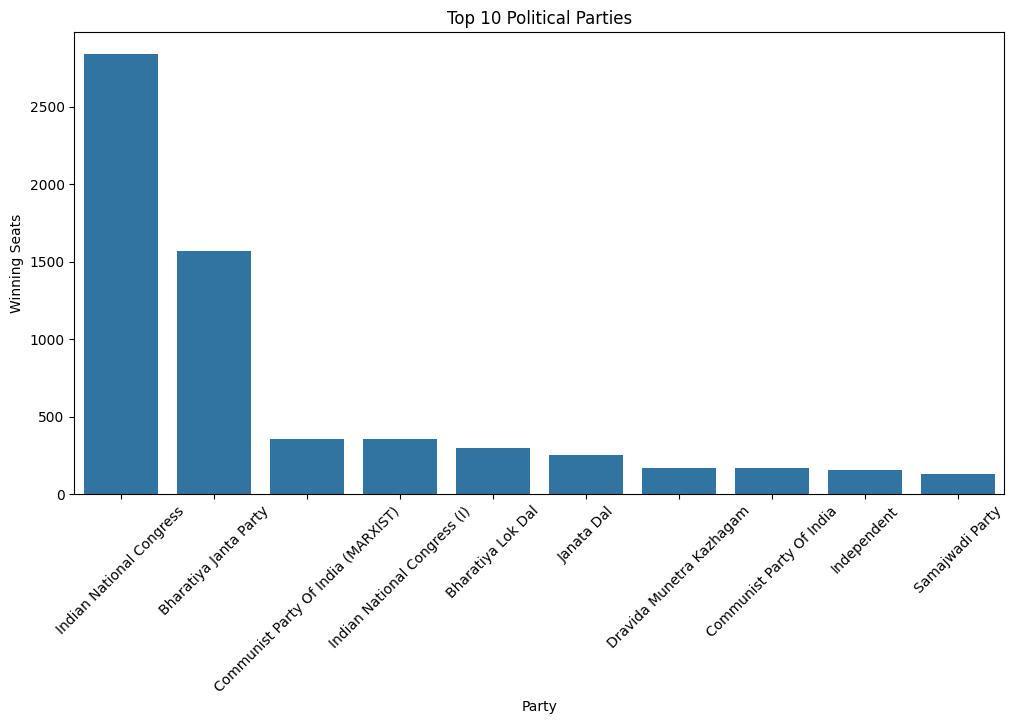

In [ ]:
top_parties = df['party'].value_counts().head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_parties.index,
    y=top_parties.values
)

plt.xticks(rotation=45)

plt.title('Top 10 Political Parties')

plt.xlabel('Party')
plt.ylabel('Winning Seats')

plt.show()

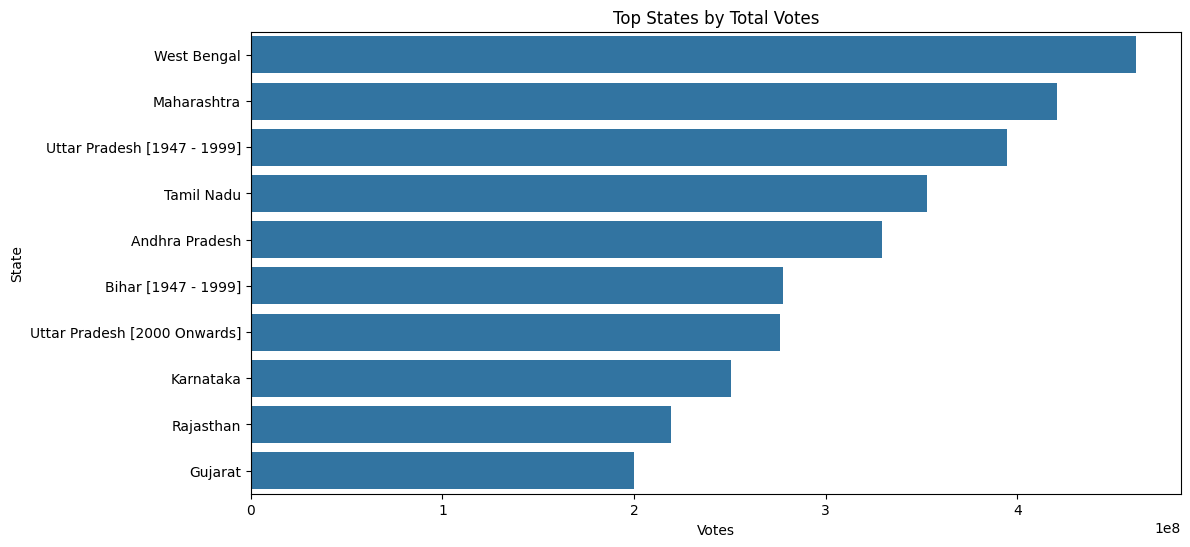

In [ ]:
top_states = (
    df.groupby('state')['votes']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_states.values,
    y=top_states.index
)

plt.title('Top States by Total Votes')

plt.xlabel('Votes')
plt.ylabel('State')

plt.show()

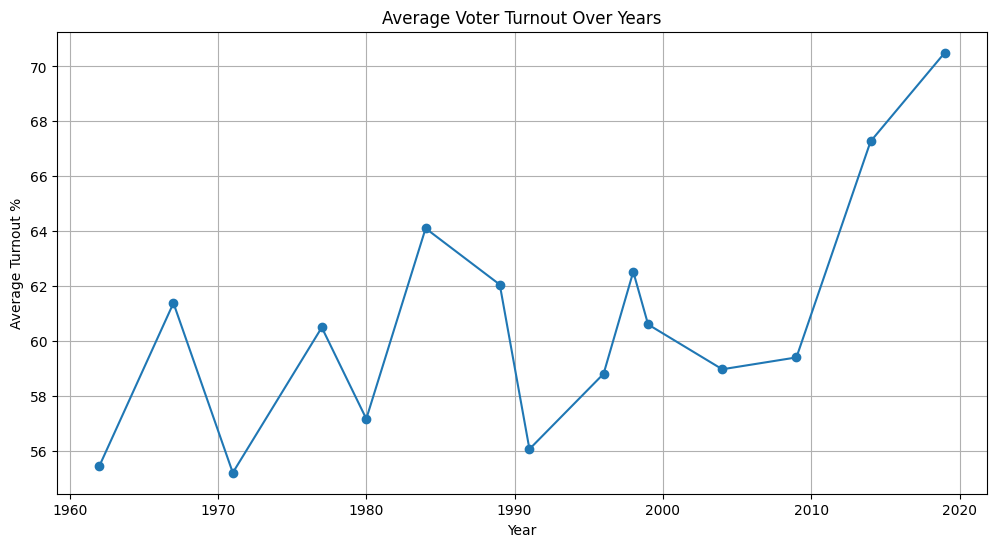

In [ ]:
turnout_year = (
    df.groupby('year')['Turnout']
    .mean()
)

plt.figure(figsize=(12,6))

plt.plot(
    turnout_year.index,
    turnout_year.values,
    marker='o'
)

plt.title('Average Voter Turnout Over Years')

plt.xlabel('Year')
plt.ylabel('Average Turnout %')

plt.grid(True)

plt.show()

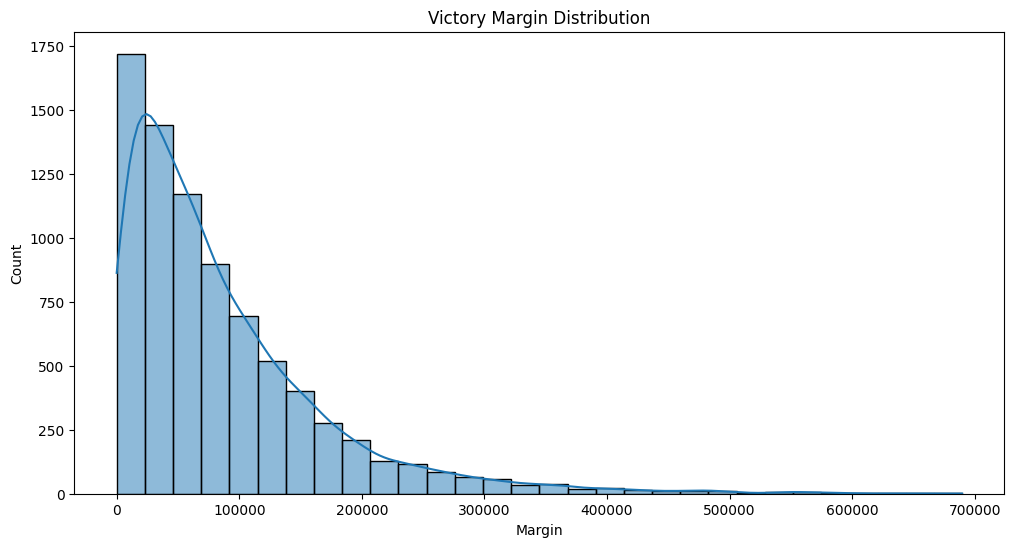

In [ ]:
plt.figure(figsize=(12,6))

sns.histplot(
    df['margin'],
    bins=30,
    kde=True
)

plt.title('Victory Margin Distribution')

plt.xlabel('Margin')

plt.show()

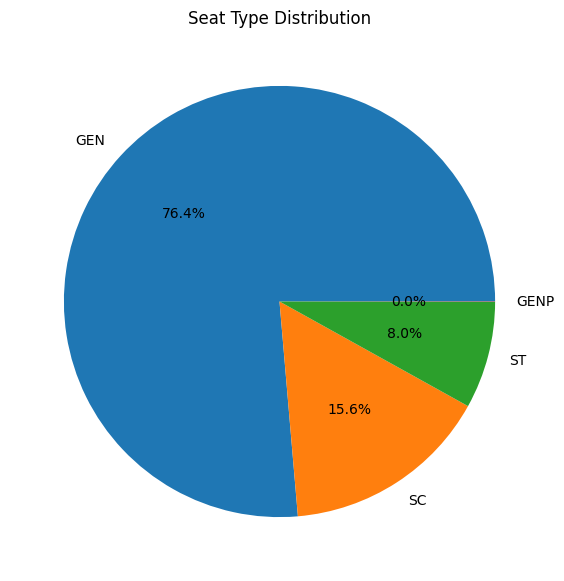

In [ ]:
seat_type = df['type'].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    seat_type.values,
    labels=seat_type.index,
    autopct='%1.1f%%'
)

plt.title('Seat Type Distribution')

plt.show()

In [ ]:
def classify_margin(x):
    if x < 5:
        return 'High Risk'
    elif x < 15:
        return 'Moderate'
    else:
        return 'Safe'

df['Victory_Risk'] = df['margin%'].apply(classify_margin)

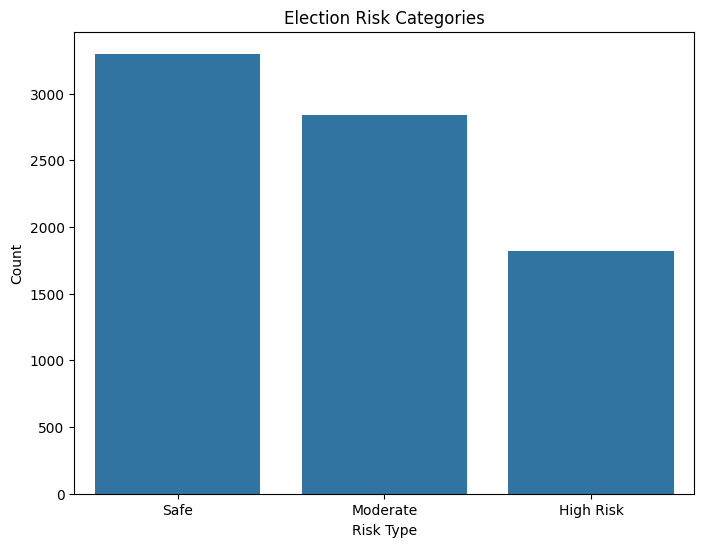

In [ ]:
risk_counts = df['Victory_Risk'].value_counts()

plt.figure(figsize=(8,6))

sns.barplot(
    x=risk_counts.index,
    y=risk_counts.values
)

plt.title('Election Risk Categories')

plt.xlabel('Risk Type')
plt.ylabel('Count')

plt.show()

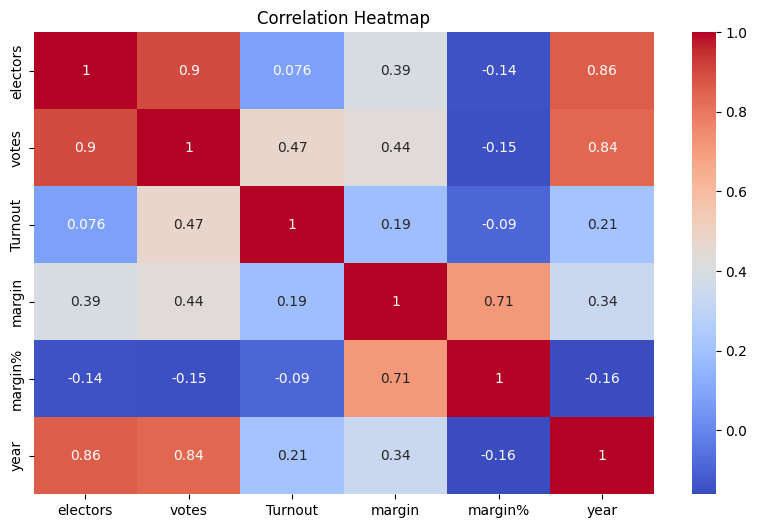

In [ ]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(10,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')

plt.show()

In [ ]:
df.to_csv('final_processed_election_data.csv', index=False)